### Steller Classification using SSDD17

#### Table of Contents:

1.**Problem Statement**.
   
2 **Introduction.**.

   
3. **Machine Learning Process.**:
   * Standard Data Exploratoary.
   * Data Preprocessing.
   * Splitting Data into Train,Test and Validation datasets.
   * Concept of Hyperparameter tuning and Grid Search CV
   * Selecting Models.
   * Implementing Decision Tree Classifier with Grid Search CV. 
   * Implementing Random Forest Classifier with Grid Search CV.
   
  

1. **Problem Statement**: The aim of this project is to do Steller Classification to predict STARS,QUASARS and GALAXY from SDSS17 datasets by implementing different classification algorithms and to get a best models through hyperparameter tuning.


2. **Introduction**

*Classification* is a supervised machine learning technique that is used for classifying or prediction of class (categorical value) from the feature variable it shares with a feature. Mathematical interpretation, it is a mapping from the feature variables to target variables, to predict categorical classes. It has various application in various fields like spam detection, image recognition (using CNN) and medical diagnosis (detection of breast cancer).

Description of dataset: The dataset that is being used here is from a space observation of SDD17. This dataset has 100,000 samples with 17 features columns and 1 target columns to predict Stars, Quasars and Galaxy. The features include  like alpha and delta(coordinates to locate position of objects in space), photo spectral features like u, v, r, z, i and other features like redshift (phenomenon where a light from an object shifts toward red end of spectrum), plates (a component to capture image of sky) , MDD(Modified Julian Date to indicate the date when particular observation has taken).

Significance of this project: This project shows application of advanced machine learning concepts in the field of astronomy,the techniques and algorithms used here are useful in terms of providing an optimized models to classify stars, and handling large astronomical data and providing valuable insights by comparative analysis of different algorithms. 

This project will use two different algorithms (Decision Tree Classifier and Random Forest Classifier) that will handle the large dataset and handle the complexity involved, reduced overfitting and for acheiving higher accuracy.

3. **Machine Learning Process**
* Standard Data Exploratoary.
* Data Preprocessing.
* Splitting Data into Train,Test and Validation datasets.
* Selecting Model.
* Implementing Machine Learning Model into training datasets.
* Hyperparameter Tuning through GridSearchCV.
* Model Evaluation.

3.A **Standard Exploratory Data Analysis**

This is a first crucial step to understand our datasets, cleaning data handling for missing values, and to provide a descriptive analysis of distribution of data.

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

In [2]:
# Reading data.
df = pd.read_csv('star_classification.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [3]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


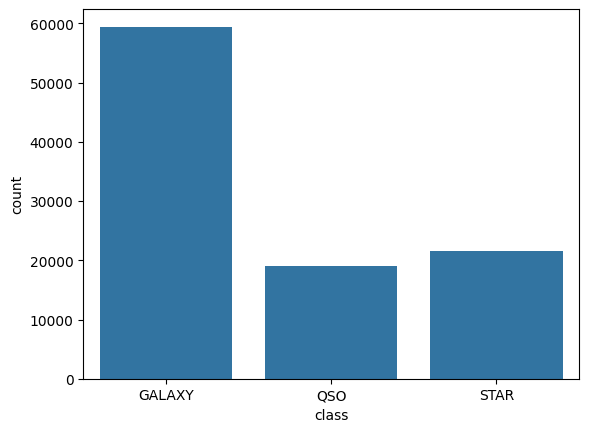

In [4]:
count_class = sbn.countplot(x = df['class'])

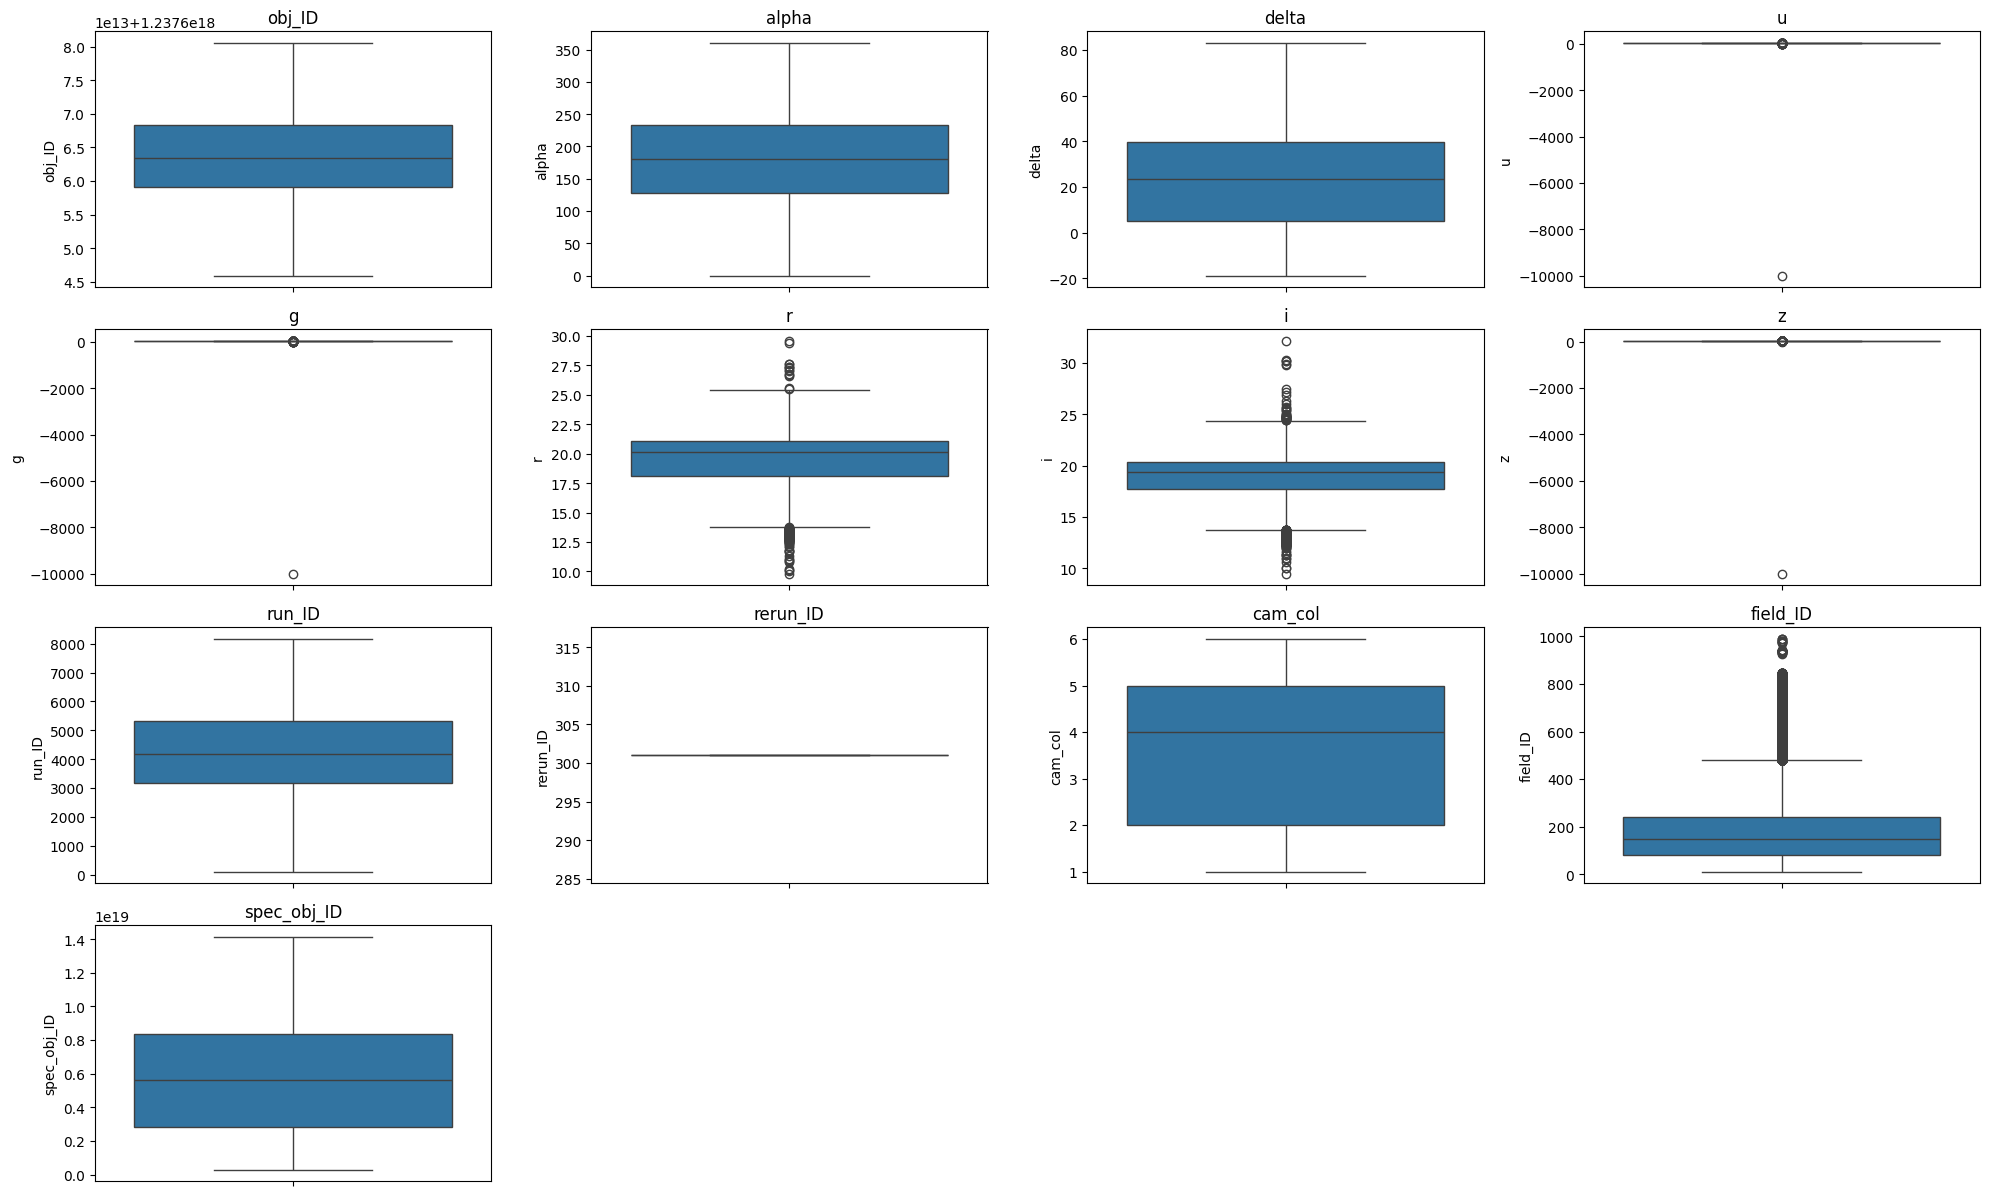

In [5]:
# creating boxplot to find a outlier
feature = df.columns[:13]
plt.figure(figsize=(20, 15))
for i, feature in enumerate(feature):
    plt.subplot(5, 4, i+1)  # Adjust the layout as needed
    sbn.boxplot(y=df[feature])
    plt.title(feature)

plt.tight_layout()
plt.show()

In [6]:
#Label encoding transforms categorical data into numerical data this will helps to perform correlation matrix
from sklearn.preprocessing import LabelEncoder

# defining label encoder
labe = LabelEncoder()

df['class'] = labe.fit_transform(df['class'])

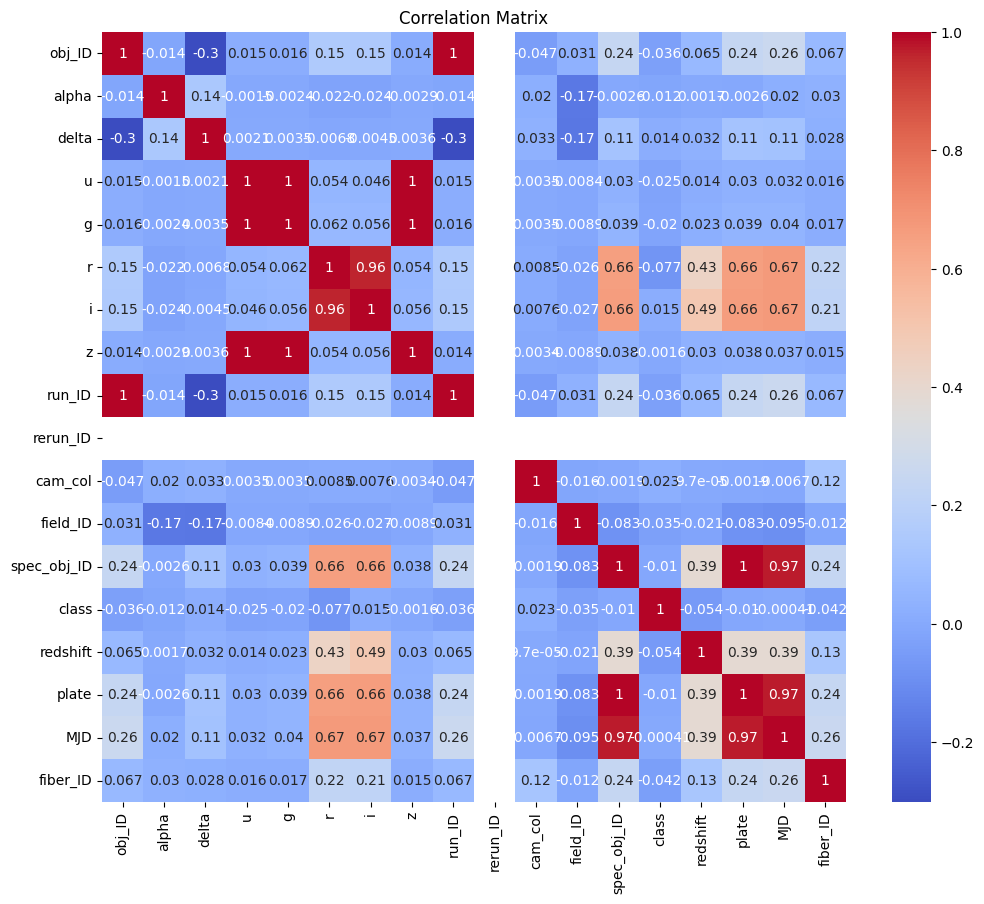

In [7]:
# creating a correlation matrix to understand the relation between our datasets
correlation_matrix = df.corr()

# visualizing correlation matrix
plt.figure(figsize=(12, 10))
sbn.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [8]:
df['class'] = labe.inverse_transform(df['class'])

#### 3.B. Data Preprocessing

This step ensures the data is transformed or scaled, encoded if it has categorical values before splitting them.

We are going to use [alpha,delta] and photospectral features like [u,g,r,i,j,z] and [redshift] to classify Steller Objects and it needs to be scaled since features have different scale and also needs to be standardize.

In [9]:
from sklearn.preprocessing import StandardScaler

# Creating X and Y variable for Features and Target Variable
X = df[['alpha','delta','u','g','r','i','z','redshift']]
Y = df['class']

# define standard scaler and transform to features X 
standardscaler = StandardScaler()
scaledX = standardscaler.fit_transform(X)
scaled_df = pd.DataFrame(scaledX,columns = X.columns)

In [10]:
scaled_df.head()

,alpha,delta,u,g,r,i,z,redshift
0,-0.434604,0.425529,0.059755,0.054926,0.403962,0.046007,0.003937,0.079557
1,-0.339921,0.363402,0.088045,0.072456,1.584406,1.185097,0.092835,0.277096
2,-0.367251,0.582713,0.103327,0.067165,0.519745,0.150019,0.008808,0.092423
3,1.669523,-1.249105,0.004921,0.102210,1.059904,0.807610,0.018321,0.486770
4,1.737310,-0.150242,-0.080055,-0.092948,-1.697421,-1.767887,-0.098468,-0.630267


3C. **Splitting Data's into Train Test and Validation Sets.** : 
A machine learning models learns from sets of training data(X,Y) and predicts the class(Y) on test datasets, sometimes training datasets need to be evaluated before testing.Therefore an original datasets must be divided into folds of train,test and validation sets.

We are going to use some features in X, based on correlation matrix and outliers to predict Y(Class).

* X = 'alpha','delta','u','g','r','i','z','redshift'
* Y = class(class contains Star,Quasars and Galaxy.)
  

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)
print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

Train set: (70000, 8), Validation set: (15000, 8), Test set: (15000, 8)


3E. **Concept of Hyperparamter Tuning and Grid Search CV.**

Every Machine learning model for example- Decision Tree Classifier, Random Forest Classifier uses different hyperparameters to perform better and for better accuracy, these parameters needs to be tune, however in order to select a better model we need information about combination of different hyperparameters of learning models and we also need multiple sets of training and validation datasets to evaluate the performance of tuned models. For achieving this task we need to tune hyperparameters by using a tool called Grid Search CV.

**Grid Search CV**: Grid Search CV is a tool for hyperparameter tuning that searches specified parameters of learning models with range of values, to find the best combination of hyperparameters of given estimator(learning model). It evaluates models on multiple folds of train, test and validation datasets with combination of different parameters. It uses arguments like-

* estimator defines the learning model that needs to be optimize.
* parameter grid is a range of values of parameters of learning models.
* cv is the number of cross validation folds.
* n jobs decides which processor needs to be used to perform the task.
* verbrose is used to returns the output.


**Selecting Models**: The model selection is based on the average performance of evaluation metrics. The combinations of hyperparameter with higest average performance over all the metrics are choosed to be best parameter for the model. The model is evaluated on Validation dataset first after Grid Search CV. After evaluating on Validation dataset it is employed on test datasets.

The model's performance is evaluated on different metrics these are:
* Precision
* Recall
* F1 Score
* Validation Score
* Test Accuracy

**Implementing Decision Tree Classifier with Grid Search CV**

Decision Tree Classifier is a supervised machine learning model, that can be thought of as tree like structure with Root Node, Parent Nodes and Terminal node. The working principle behind is that it predicts a class by partitioning feature space(input space = X) into parent nodes using thresold conditions and on feature attributes, and it predicts classes at the leaf node after splitting parent nodes or child nodes. The splitting criteria of any node is determined by minimizing the loss on nodes. The algorithm tries to minimize the loss on nodes using splitting criteria like Entropy Gain or Gini Index. 

Mathematically, In Decision Tree Classifier a Split function $S_{p}(j,t)$ tries to split the parent region $R_{p}$ into child nodes lets say R_{1} and R_{2} using thresold value of feature and treats new partitioned space as a new problem and splits it further, during the split process the algorithm tries to minimize the loss on nodes using Entropy Gain $E(S)$ [that measures the disorder] or Gini Index $E(S)$ [that measure the probability of misclassification] in nodes using splitting criterion.

Split function splits the parent region into child nodes and is given by:

$$ S_{p}(j,t) = \set {X|X_{j}>t, X \in R_{p}} 
\set {X|X_{j}\geq t, X \in R_{p}}$$

The Loss on node is defined by:

$$ Loss(R_{p}) = Loss_{min}(R_{P}) - \frac {Loss(R_1 + R_2)}{2}$$

where:

$R_{p}$ is Parent Node,
$R_{1}$ and $R_{2}$ are child nodes.



Entropy Loss on parent node before split that has proportion of class C: 

$$E(S) = \sum_{i=1}^{c} -\hat{p}{i} \log_{2} \hat{p}_{i}$$

where:
$E(S)$ is entropy gain,
$\hat p_{c}$ is proportion of class C in parent region.


Gini Loss on parent node before split:
$$Gini(E) = 1-\sum_{j = 1}^{c}.p^2_j$$

where:
$Gini(E)$ is gini index,
$p_(j)$ is the probability of instance that belongs to class C,
$c$ is class. 


Decision Tree Classifier along with splitting criteria uses several parameters in order to predict class effectively like-

* The depth of tree sets the depth of tree.
* min_sample_split sets the number of datapoints required at the parent nodes for splitting.
* min_sample_leaf sets the number of datapoints required at the leaf node for splitting.


In [12]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# define a decision tree classifier
dtc = DecisionTreeClassifier()

# Define hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],       # Splitting criteria
    'max_depth': [None, 10, 20, 30],        # Tree depth
    'min_samples_split': [2, 5, 10],        # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4]           # Minimum samples in leaf nodes
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, Y_train)

# Get best parameters
print("Best Parameters:", grid_search.best_params_)

# Validate the best model
best_dtc = grid_search.best_estimator_
val_predictions = best_dtc.predict(X_val)
val_accuracy = accuracy_score(Y_val, val_predictions)
print(f"Validation Accuracy: {val_accuracy}")

# Test the best model
test_predictions = best_dtc.predict(X_test)
test_accuracy = accuracy_score(Y_test, test_predictions)
print(f"Test Accuracy: {test_accuracy}");

# Evaluate the final model on the test set
test_predictions = best_dtc.predict(X_test)
test_accuracy = accuracy_score(Y_test, test_predictions)
print("Classification Report:\n", classification_report(Y_test, test_predictions));

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Validation Accuracy: 0.9744666666666667
Test Accuracy: 0.9746666666666667
Test Accuracy: 0.9746666666666667
Classification Report:
               precision    recall  f1-score   support

      GALAXY       0.97      0.99      0.98      8927
         QSO       0.96      0.92      0.94      2813
        STAR       1.00      1.00      1.00      3260

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



Resuts and Analysis:
* The best parameter for Decision Tree Classifier has splitting criterion: Entropy, maximum depth of tree: 10, min_sample_leaf: 4, min_samples_split: 10.

* A comprehensive classification report for Decision Tree Classifier that measures precision, recall, f1-score and support for predicting each individual classes.

* Model is able to acheive an accuracy rate of more than 97% on validation and test dataset.

**Implementing Random Forest Classifier with Grid Search CV**

A Random Forest Classifier is a machine learning algorithm that uses multiple decision trees to predict a class by splitting the datapoints from random subset of features. The decision tree is trained on random subsets of datapoints and based on splitting criteria.The maximum depth allows the tree to grow continuosly until leaf node has no impurity. The predicted class of Random Forest is a result from the aggregation of majority vote of predicted class casted by Decision tree.

The predicted class in Random Forest Classifier is given by:
$$ \hat{y} = \text{mode}(h_1(x), h_2(x), \ldots, h_{N_{trees}}(x)) $$

where:
$\hat y$ is predicted class.
h_1(x)...h_{N_{trees}}(x) are the predicted classes of individual trees.

The Random Forest Classifier uses several parameters to predict class effectively these are-

* Number of Estimatiors defines the number of decision tree that random forest classifier use.
* Maximum depth of Tree sets the depth of decision tree.
* min_samples_split to set the minimum no. of datapoints required at parent node before splitting.
* min_samples_leaf determines miniumum no. of datapoints required in the leaf node.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define a RandomForest model
rfc = RandomForestClassifier(random_state=42)

# Define hyperparameters to tune
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=3, n_jobs=-1, verbose=0)
grid_search.fit(X_train, Y_train)

print("Best Parameters:", grid_search.best_params_)

# Validate the model on the validation set
best_rfc = grid_search.best_estimator_
val_predictions = best_rfc.predict(X_val)
val_accuracy = accuracy_score(Y_val, val_predictions)
print(f"Validation Accuracy: {val_accuracy}")

# Evaluate the final model on the test set
test_predictions = best_rfc.predict(X_test)
test_accuracy = accuracy_score(Y_test, test_predictions)
print(f"Test Accuracy: {test_accuracy}")
print("Classification Report:\n", classification_report(Y_test, test_predictions));

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Validation Accuracy: 0.9767333333333333
Test Accuracy: 0.9786666666666667
Classification Report:
               precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98      8927
         QSO       0.97      0.93      0.95      2813
        STAR       0.99      1.00      1.00      3260

    accuracy                           0.98     15000
   macro avg       0.98      0.97      0.97     15000
weighted avg       0.98      0.98      0.98     15000



Results and Analysis:

1. Best Parameter for Random Forest Classifier has Maximum Depth of tree: 20, number of decision trees :200, minimum sample splits: 5 and minimum sample leaf: 1.

2. A comprehensive Report for Random Forest Classifier to measure Precision, Recall, f1 score and support for each classes.

3. Model is able to acheive an accuracy rate of more than 97% on validation and test dataset.